In [1]:
import sys, re, json
sys.path.append('..') 

from scripts.constants import *
from scripts.utils import *
from scripts.sedona_config import *
from scripts.utils import translate_tile_name

import pandas as pd
import geopandas as gpd
from tqdm import tqdm

In [2]:
geo_level = 'LAD22CD'
geo_code = 'E08000027'
buffer = 100

In [3]:
project_crs = 'EPSG:27700'

# IN paths
vom_dir = RASTER_IN_DIR / "Defra" / "VOM"
vom_lad_dir = vom_dir / "LADs"
chm_lad_tiles_path = vom_lad_dir / "LAD_CHM_tiles_paths.json"
T3_30_300_DIR = VECTOR_OUT_DIR / "3-30-300"
T3_dir = T3_30_300_DIR / "T3"
trees_dir = T3_30_300_DIR / "VOM_Trees"
os_5km_boundaries_path = VECTOR_IN_DIR / "OS" / "National_Grid" / "5km_grid_region.shp"
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.parquet"

chm_lad_tiles_dict = json.load(open(chm_lad_tiles_path))
os_5km_boundaries_gdf = gpd.read_file(os_5km_boundaries_path).to_crs(project_crs)
imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_boundaries_path)
imd_lsoa_bua_buffer_gdf = imd_lsoa_bua_gdf.copy()
imd_lsoa_bua_buffer_gdf['geometry'] = imd_lsoa_bua_buffer_gdf['geometry'].buffer(buffer)
geo_level_codes = imd_lsoa_bua_gdf[geo_level].unique()

os.environ["JAVA_HOME"] = JAVA_HOME
sedona = get_spark()

25/03/11 11:41:20 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
25/03/11 11:41:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-64e745e6-2fe6-43f7-8efd-71750dca5f71;1.0
	confs: [default]


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/miniconda3/envs/3-30-300-env/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.0 in central
	found org.apache.sedona#sedona-common;1.7.0 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.error

In [4]:
boundaries_sdf = sedona.createDataFrame(imd_lsoa_bua_gdf.drop(columns=['LSOA21NMW', 'LAD22NMW', 'BUA22NMG', 'BUA22NMW', 'RGN22NMW'], axis=1))
boundaries_sdf.createOrReplaceTempView('boundaries')
buildings_sdf = sedona.read.format("geoparquet").load(str(buildings_path))
buildings_sdf.createOrReplaceTempView("buildings")

In [5]:
def extract_grid_reference(filename: str) -> str|None:
    """
    Extracts a grid reference from a given filename.
    The function searches for a pattern in the filename that matches 'VOM' or 'VOM_HS'
    followed by an underscore, a two-letter code, a four-digit number, and another underscore.
    If such a pattern is found, it returns the grid reference (the two-letter code and the four-digit number).
    If no match is found, it returns None.
    Parameters:
        filename (str | Path): The name of the file from which to extract the grid reference.
    Returns:
        str | None: The extracted grid reference if a match is found, otherwise None.
    """

    match = re.search(r'VOM_([A-Z]{2}\d{4})_', filename)
    if match:
        return match.group(1)
    return None

def check_tree_vom_pair(chm_path: str|Path, trees_dir: str|Path) -> bool:
    """
    Check if a CHM file has a corresponding tree file.
    Parameters:
        chm_path (str | Path): The path to the CHM file.
        trees_dir (str | Path): The directory containing the tree files.
    Returns:
        bool: True if a corresponding tree file exists, otherwise False.
    """

    tile_name = extract_grid_reference(chm_path)
    chm_path = chm_path if isinstance(chm_path, Path) else Path(chm_path)
    year = chm_path.parent.name

    trees_path = trees_dir / f"VOM_trees_{tile_name}_{year}.gpkg"

    if trees_path.exists():
        return str(trees_path)
    
def process_vom_tiles(trees_path_lst: list, tree_area: int=10, tree_height: int=3) -> gpd.GeoDataFrame:

    logging.warning(f"Reading {len(trees_path_lst)} VOM tiles")
    if len(trees_path_lst) > 1:
        
        trees_gdf_lst = [gpd.read_file(tree_path) for tree_path in trees_path_lst]
        merged_trees_gdf = gpd.GeoDataFrame(pd.concat(trees_gdf_lst, ignore_index=True))
    elif len(trees_path_lst) == 1: 
        merged_trees_gdf = gpd.read_file(trees_path_lst[0])

    else:
        return None

    geo_trees_gdf = merged_trees_gdf[(merged_trees_gdf.area > tree_area) & (merged_trees_gdf.height > tree_height)].reset_index(drop=True)
    geo_trees_gdf['treeID'] = range(len(geo_trees_gdf))

    return geo_trees_gdf

def process_buildings(geo_level: str, geo_code: str) -> None:

    logging.warning(f"Filtering buildings for {geo_code}")

    geo_boundary_sdf = sedona.sql(
        f"""
            SELECT ST_Union_Aggr(geometry) AS geometry
            FROM boundaries
            WHERE {geo_level} = '{geo_code}'
        """)
    geo_boundary_sdf.createOrReplaceTempView("geo_boundary")

    geo_buildings_sdf = sedona.sql(
        """
            SELECT b.* FROM buildings b, geo_boundary g 
            WHERE ST_Intersects(b.geometry, g.geometry)
        """)
    geo_buildings_sdf.createOrReplaceTempView("geo_buildings")

    geo_buildings_buffer_sdf = sedona.sql(
        """
            SELECT ST_Buffer(b.geometry, 100) AS geometry, b.verisk_premise_id
            FROM geo_buildings b
        """)
    geo_buildings_buffer_sdf.createOrReplaceTempView("building_buffers")

    return geo_buildings_buffer_sdf

def count_trees(geo_level: str, geo_code: str) -> pd.DataFrame:

    logging.warning(f"Counting trees for each building in {geo_code}")

    trees_within_buffer_sdf = sedona.sql(
        """
            SELECT b.verisk_premise_id, COUNT(t.treeID) AS tree_count
            FROM building_buffers b
            LEFT JOIN geo_trees t
            ON ST_Intersects(b.geometry, t.geometry)
            GROUP BY b.verisk_premise_id
        """)
    
    trees_within_buffer_df = trees_within_buffer_sdf.toPandas()

    return trees_within_buffer_df

def get_overlapping_tiles(imd_lsoa_bua_buffer_gdf, os_5km_boundaries_gdf, geo_level, geo_code):
    # Select one feature from imd_lsoa_bua_buffer_gdf
    selected_feature = imd_lsoa_bua_buffer_gdf[imd_lsoa_bua_buffer_gdf[geo_level] == geo_code]

    # Get the overlapping features
    overlapping_tiles_lst = gpd.overlay(selected_feature, os_5km_boundaries_gdf, how='intersection')['TILE_NAME'].unique().tolist()

    return overlapping_tiles_lst

def get_vom_trees_paths(overlapping_tiles_lst: list, vom_tree_pair_dict: dict) -> list:

    vom_trees_path_lst = list(set([path_pair[1] for _,v in vom_tree_pair_dict.items() for path_pair in v if path_pair[1] is not None]))
    trees_path_lst = []
    for tile_name in overlapping_tiles_lst:
        translated_tile_name = translate_tile_name(tile_name).upper()
        tile_path = [path for path in vom_trees_path_lst if translated_tile_name in path]
        trees_path_lst.append(tile_path[0])

    return trees_path_lst


def process_geo_code(geo_level: str, geo_code: str, vom_tree_pair_dict: dict,
                     imd_lsoa_bua_buffer_gdf: gpd.GeoDataFrame, os_5km_boundaries_gdf: gpd.GeoDataFrame,
                     tree_area: int=10, tree_height: int=3) -> None:

    start_time = time.time()

    T3_dir = VECTOR_OUT_DIR / "3-30-300" / "T3"
    T3_dir.mkdir(parents=True, exist_ok=True)
    tree_count_path = T3_dir / f"T3_{geo_code}.csv"
    if not tree_count_path.exists():
        try:
            overlapping_tiles_lst = get_overlapping_tiles(imd_lsoa_bua_buffer_gdf, os_5km_boundaries_gdf, geo_level, geo_code)
            trees_path_lst = get_vom_trees_paths(overlapping_tiles_lst, vom_tree_pair_dict)

            geo_trees_gdf = process_vom_tiles(trees_path_lst, tree_area=tree_area, tree_height=tree_height)
            geo_trees_sdf = sedona.createDataFrame(geo_trees_gdf)
            geo_trees_sdf.createOrReplaceTempView("geo_trees")

            process_buildings(geo_level, geo_code)

            trees_within_buffer_df = count_trees(geo_level, geo_code)

            trees_within_buffer_df.to_csv(tree_count_path, index=False)
            
            logging.warning(f"Saving file for {geo_code} with {len(trees_within_buffer_df)} records")

            end_time = time.time()
            logging.warning(f"Processing for {geo_code} took {end_time - start_time:.2f} seconds")

        except Exception as e:
            logging.error(f"Error processing {geo_code}: {e}")
   

In [6]:
vom_tree_pair_dict = {k: [(chm_path, check_tree_vom_pair(chm_path, trees_dir)) for chm_path in v] for k, v in chm_lad_tiles_dict.items()}

In [7]:
tree_area: int=10
tree_height: int=3
T3_dir = VECTOR_OUT_DIR / "3-30-300" / "T3"
T3_dir.mkdir(parents=True, exist_ok=True)
tree_count_path = T3_dir / f"T3_{geo_code}.csv"

# overlapping_tiles_lst = get_overlapping_tiles(imd_lsoa_bua_buffer_gdf, os_5km_boundaries_gdf, geo_level, geo_code)
# trees_path_lst = get_vom_trees_paths(overlapping_tiles_lst, vom_tree_pair_dict)

# geo_trees_gdf = process_vom_tiles(trees_path_lst, tree_area=tree_area, tree_height=tree_height)
# geo_trees_sdf = sedona.createDataFrame(geo_trees_gdf)
# geo_trees_sdf.createOrReplaceTempView("geo_trees")

geo_buildings_buffer_sdf = process_buildings(geo_level, geo_code)
# y = process_buildings(geo_level, geo_code)

# trees_within_buffer_df = count_trees(geo_level, geo_code)
    

In [8]:
def format_os_national_grid(os_5km_boundaries_gdf, tile_level):

    def translate_code(code):
        ew = 'W' if int(code[2]) < 5 else 'E'
        ns = 'S' if int(code[3]) < 5 else 'N'
        return code[:2] + ns + ew
    
    os_5km_boundaries_gdf.rename(columns={'TILE_NAME': 'TILE_NAME_5KM'}, inplace=True)

    os_5km_boundaries_gdf['TILE_NAME_10KM'] = os_5km_boundaries_gdf['TILE_NAME_5KM'].apply(lambda x: x[:4])
    os_5km_boundaries_gdf['TILE_NAME_50KM'] = os_5km_boundaries_gdf['TILE_NAME_5KM'].apply(translate_code)
    os_5km_boundaries_gdf['TILE_NAME_100KM'] = os_5km_boundaries_gdf['TILE_NAME_5KM'].apply(lambda x: x[:2])
    os_5km_boundaries_gdf = os_5km_boundaries_gdf[['TILE_NAME_5KM', 'TILE_NAME_10KM', 'TILE_NAME_50KM', 'TILE_NAME_100KM', 'geometry']]

    os_tile_boundaries_gdf = os_5km_boundaries_gdf.dissolve(tile_level).reset_index()[[tile_level, 'geometry']]
    
    return os_tile_boundaries_gdf

def get_overlapping_grid_tiles(imd_lsoa_bua_buffer_gdf, os_tile_boundaries_gdf, geo_level, geo_code, tile_level):
    # Select one feature from imd_lsoa_bua_buffer_gdf
    selected_feature = imd_lsoa_bua_buffer_gdf[imd_lsoa_bua_buffer_gdf[geo_level] == geo_code]

    overlapping_tiles_gdf = gpd.overlay(selected_feature, os_tile_boundaries_gdf, how='intersection')
    overlapping_tiles_lst = overlapping_tiles_gdf[tile_level].unique().tolist()

    return overlapping_tiles_lst

def read_vom_trees_geoparquet(sedona, overlapping_tiles_lst):

    vom_trees_dir = T3_30_300_DIR / "VOM_Trees_geoparquet"
    vom_trees_paths = [str(path) for path in vom_trees_dir.glob("*.geoparquet") if any(tile_name in path.name for tile_name in overlapping_tiles_lst)]
    geo_trees_sdf = sedona.read.format("geoparquet").load(vom_trees_paths)
    geo_trees_sdf.createOrReplaceTempView("buildings")

    return geo_trees_sdf

def create_spatial_rdds(geo_buildings_buffer_sdf, geo_trees_sdf):

    geo_buildings_buffer_rdd  = Adapter.toSpatialRdd(geo_buildings_buffer_sdf, 'geometry')
    geo_trees_rdd = Adapter.toSpatialRdd(geo_trees_sdf, 'geometry')
    
    geo_buildings_buffer_rdd.analyze()
    geo_trees_rdd.analyze()
    
    return geo_buildings_buffer_rdd, geo_trees_rdd

def count_trees_rdd(sedona, geo_buildings_buffer_rdd, geo_trees_rdd, build_on_spatial_partitioned_rdd = True, using_index = True):

    geo_trees_rdd.spatialPartitioning(GridType.KDBTREE)
    geo_buildings_buffer_rdd.spatialPartitioning(geo_trees_rdd.getPartitioner())
    
    geo_buildings_buffer_rdd.buildIndex(IndexType.QUADTREE, build_on_spatial_partitioned_rdd)

    query_result = JoinQueryRaw.SpatialJoinQueryFlat(geo_trees_rdd, geo_buildings_buffer_rdd, using_index, True)

    query_result_df = Adapter.toDf(query_result, ["verisk_premise_id"], ["treeID"], sedona)

    query_result_df = query_result_df.toPandas().sort_values(by='verisk_premise_id')

    trees_within_buffer_df = query_result_df.groupby('verisk_premise_id').size().reset_index(name='tree_count')

    return trees_within_buffer_df

In [9]:
tile_level = 'TILE_NAME_50KM'
os_tile_boundaries_gdf = format_os_national_grid(os_5km_boundaries_gdf, tile_level)

overlapping_tiles_lst = get_overlapping_grid_tiles(imd_lsoa_bua_buffer_gdf, os_tile_boundaries_gdf, geo_level, geo_code, tile_level)
overlapping_tiles_lst

['SONE']

In [10]:
geo_trees_sdf = read_vom_trees_geoparquet(sedona, overlapping_tiles_lst)
geo_trees_sdf

DataFrame[treeID: bigint, height: double, area: double, geometry: udt]

In [11]:
type(geo_buildings_buffer_sdf)

pyspark.sql.dataframe.DataFrame

In [12]:
geo_buildings_buffer_rdd, geo_trees_rdd = create_spatial_rdds(geo_buildings_buffer_sdf, geo_trees_sdf)

In [19]:
print("Geo Trees RDD Sample:", geo_trees_rdd.rawSpatialRDD.take(1))
print("Spectral RDD Sample:", geo_buildings_buffer_rdd.rawSpatialRDD.take(1))

Geo Trees RDD Sample: [Geometry: Point userData: 0	4.367000579833984	68.048039303525]


Spectral RDD Sample: [Geometry: Polygon userData: 26816075]


In [12]:
trees_within_buffer_df = count_trees_rdd(sedona, geo_buildings_buffer_rdd, geo_trees_rdd, build_on_spatial_partitioned_rdd = True, using_index = True)
trees_within_buffer_df

,verisk_premise_id,tree_count
0,1028897,7
1,1051838,67
2,1069313,79
3,1083601,51
4,1083634,27
...,...,...
147761,835421,51
147762,855380,11
147763,889471,83
147764,935338,26


In [22]:
vom_trees_dir = T3_30_300_DIR / "VOM_Trees_geoparquet"
vom_trees_paths = [str(path) for path in vom_trees_dir.glob("*.geoparquet")]
geo_trees_sdf = sedona.read.format("geoparquet").load(str(vom_trees_dir))

DataFrame[treeID: bigint, height: double, area: double, geometry: udt]

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Ensure the number of colors is at least as many as the number of unique features
num_colors = len(os_tile_boundaries_gdf.TILE_NAME_50KM.unique())

# Generate a colormap with the required number of colors
colors = plt.cm.get_cmap('tab20', num_colors).colors

# Create a colormap object
cmap = mcolors.ListedColormap(colors)

# Plot the GeoDataFrame with the colormap
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
os_tile_boundaries_gdf.plot(column='TILE_NAME_50KM', cmap=cmap, linewidth=0.8, ax=ax, edgecolor='0.8')

# Remove axis for better visualization
ax.set_axis_off()

# Add a title
plt.title('Choropleth Map of 5km Boundaries', fontsize=15)

# Show the plot
plt.show()

In [7]:
import re

def extract_grid_reference_from_path(path: str) -> str:
    match = re.search(r'VOM_trees_([A-Z]{2}\d{4})_', path)
    if match:
        return match.group(1)
    return None

vom_trees_path_lst = list(set([path_pair[1] for _,v in vom_tree_pair_dict.items() for path_pair in v if path_pair[1] is not None]))
grid_references = [translate_tile_name(extract_grid_reference_from_path(path)) for path in vom_trees_path_lst]
grid_references.sort()
grid_references

['NT60NE',
 'NT60SE',
 'NT60SW',
 'NT70NE',
 'NT70NW',
 'NT70SE',
 'NT70SW',
 'NT71SE',
 'NT73NE',
 'NT80NE',
 'NT80NW',
 'NT80SE',
 'NT80SW',
 'NT81NW',
 'NT81SE',
 'NT81SW',
 'NT82NE',
 'NT82NW',
 'NT82SE',
 'NT83NE',
 'NT83NW',
 'NT83SE',
 'NT83SW',
 'NT84NE',
 'NT84SE',
 'NT84SW',
 'NT90NE',
 'NT90NW',
 'NT90SE',
 'NT90SW',
 'NT91NE',
 'NT91NW',
 'NT91SE',
 'NT91SW',
 'NT92NE',
 'NT92NW',
 'NT92SE',
 'NT92SW',
 'NT93NE',
 'NT93NW',
 'NT93SE',
 'NT93SW',
 'NT94NE',
 'NT94NW',
 'NT94SE',
 'NT94SW',
 'NT95NE',
 'NT95NW',
 'NT95SE',
 'NT95SW',
 'NU00NE',
 'NU00NW',
 'NU00SE',
 'NU00SW',
 'NU01NE',
 'NU01NW',
 'NU01SE',
 'NU01SW',
 'NU02NE',
 'NU02NW',
 'NU02SE',
 'NU02SW',
 'NU03NE',
 'NU03NW',
 'NU03SE',
 'NU04NE',
 'NU04NW',
 'NU04SE',
 'NU04SW',
 'NU05SW',
 'NU10NE',
 'NU10NW',
 'NU10SE',
 'NU10SW',
 'NU11NE',
 'NU11NW',
 'NU11SE',
 'NU11SW',
 'NU12NE',
 'NU12NW',
 'NU12SE',
 'NU12SW',
 'NU13NE',
 'NU13NW',
 'NU13SE',
 'NU13SW',
 'NU14SW',
 'NU20NE',
 'NU20NW',
 'NU20SE',
 'NU20SW',

<Axes: >

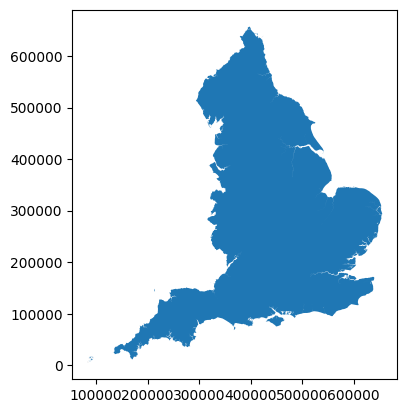

In [8]:
imd_lsoa_bua_dissolved_gdf = imd_lsoa_bua_gdf.dissolve()
imd_lsoa_bua_dissolved_gdf.plot()

In [22]:
x = gpd.overlay(os_5km_boundaries_gdf, imd_lsoa_bua_dissolved_gdf, how='intersection')

<Axes: >

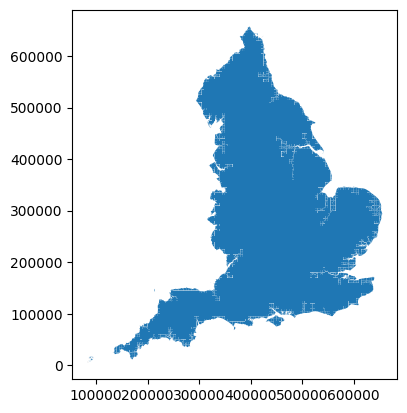

In [23]:
x.plot()

In [11]:
non_urban_vom_tiles = os_5km_boundaries_gdf[~os_5km_boundaries_gdf['TILE_NAME'].isin(grid_references)]
urban_vom_tiles = os_5km_boundaries_gdf[os_5km_boundaries_gdf['TILE_NAME'].isin(grid_references)]

<Axes: >

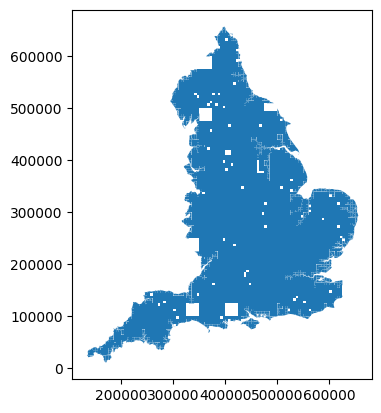

In [12]:
urban_vom_tiles_in_bua = gpd.overlay(urban_vom_tiles, imd_lsoa_bua_dissolved_gdf, how='intersection')
urban_vom_tiles_in_bua.plot()

<Axes: >

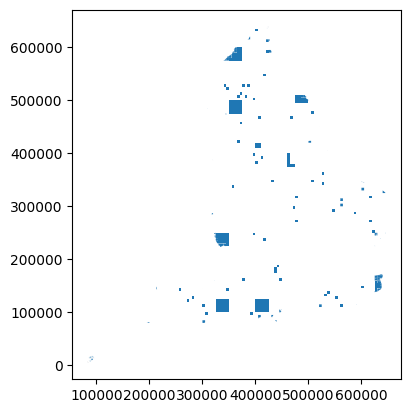

In [10]:
non_urban_vom_tiles_in_bua = gpd.overlay(non_urban_vom_tiles, imd_lsoa_bua_dissolved_gdf, how='intersection')
non_urban_vom_tiles_in_bua.plot()

In [60]:
len(non_urban_vom_tiles_in_bua.TILE_NAME.unique())

281

In [13]:
import requests

def download_file(url: str, filename: str, folder_path: Path) -> int:
    
    # Get the filename from the URL
    file_path = folder_path / filename
    
    # Download the file
    response = requests.get(url)
    # response.raise_for_status()  # Check if the request was successful

    if response.status_code == 200 and not os.path.exists(file_path):
         # Ensure the folder exists
        folder_path.mkdir(parents=True, exist_ok=True)
        
        # Save the file
        with open(file_path, 'wb') as file:
            file.write(response.content)

    return response.status_code

def translate_tile_name(tile_name: str) -> str:
    
    NS_dict = {'S': '0', 'N': '5'}
    EW_dict = {'W': '0', 'E': '5'} 

    assert len(tile_name) == 6
    
    code = tile_name[2:6].upper()
    try: # If input is like TL0045
        int(code)
        NS_dict = {v: k for k, v in NS_dict.items()}
        EW_dict = {v: k for k, v in EW_dict.items()}
        ns_id = code[3]
        ew_id = code[1]
        direction_code = code[0] + code[2] + NS_dict[ns_id] + EW_dict[ew_id]
        trans_tile_name = tile_name[:2].upper() + direction_code
    except ValueError: # If input is like TL04NW
        ns_id = code[2]
        ew_id = code[3]
        number_code = code[0] + EW_dict[ew_id] + code[1] + NS_dict[ns_id]
        trans_tile_name = tile_name[:2].lower() + number_code

    return trans_tile_name

def download_tiles_geography(tile_list: list[str], url: str, folder_path: Path) -> pd.DataFrame:

    years = ['2018', '2019', '2020', '2021', '2022', '2023']
    # first_number = ['0','1','2','3','4','5']
    # second_number = ['6', '7', '8', '9']
    # directions = ['SW', 'SE', 'NE', 'NW']
    # tile_names = ['TQ' + a + b + c for a in first_number for b in second_number for c in directions]
    tile_log_df = pd.DataFrame()
    print(tile_list)
    for tile in tile_list:
        for year in years:
            try: 
                year_folder_path = folder_path / year
                tile_url = url.format(year, translate_tile_name(tile).upper())
                status = download_file(tile_url, f"lidar_vom_{tile}.zip", year_folder_path)

                if status == 200:
                    tile_df = pd.DataFrame({'TILE_NAME': [tile], 'year': [year]})

                    tile_log_df = pd.concat([tile_log_df, tile_df], ignore_index=True)
            except:
                continue
    return tile_log_df

In [20]:
urban_vom_tiles_in_bua

AttributeError: 'NoneType' object has no attribute 'copy'

,TILE_NAME,LSOA11CD,LSOA11NM,LSOA21CD,LSOA21NM,LSOA21NMW,LAD22CD,LAD22NM,LAD22NMW,BUA22CD,BUA22NMW,BUA22NMG,RGN22NMW,BUA22NM,RGN22CD,RGN22NM,geometry
0,NT60NE,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"POLYGON ((369999.999 605000, 368252.331 605000..."
1,NT60SE,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"POLYGON ((369999.999 605000, 369999.999 600000..."
2,NT60SW,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"POLYGON ((364999.996 600000.001, 362903.071 60..."
3,NT70NE,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"POLYGON ((379999.997 609999.998, 379999.997 60..."
4,NT70NW,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"POLYGON ((375000.002 605000, 369999.999 605000..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5349,TV49NE,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"MULTIPOLYGON (((549999.997 100000.004, 549999...."
5350,TV49NW,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"POLYGON ((544889.578 100000.004, 544791.3 9995..."
5351,TV59NE,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"POLYGON ((560000.003 100000.004, 560000.003 96..."
5352,TV59NW,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,Croesoswallt,None,None,City and County of the City of London,E12000007,London,"MULTIPOLYGON (((551139.149 100000.004, 551082 ..."


In [19]:
base_url = "https://api.agrimetrics.co.uk/tiles/collections/survey/national_lidar_programme_vom/{}/1/{}?subscription-key=public"
vom_dir = RASTER_IN_DIR / "Defra" / "VOM_rural"
roi_vom_tiles_path = vom_dir / f"rural_VOM_tiles.csv"
vom_dir.mkdir(parents=True, exist_ok=True)
roi_tiles_df = download_tiles_geography(non_urban_vom_tiles_in_bua['TILE_NAME'].unique(), base_url, vom_dir)
roi_tiles_df.to_csv(roi_vom_tiles_path, index=False)

['NT81NE' 'NU03SW' 'NU21SE' 'NU21SW' 'NU23NW' 'NY37NE' 'NY42NW' 'NY42SE'
 'NY47NE' 'NY47NW' 'NY48SE' 'NY57NE' 'NY57NW' 'NY58NE' 'NY58NW' 'NY58SE'
 'NY58SW' 'NY59NE' 'NY59SE' 'NY60NE' 'NY67NE' 'NY67NW' 'NY68NE' 'NY68NW'
 'NY68SE' 'NY68SW' 'NY69NE' 'NY69NW' 'NY69SE' 'NY69SW' 'NY71SW' 'NY72NE'
 'NY77NW' 'NY78NW' 'NY78SW' 'NY79NW' 'NY79SW' 'NY80NW' 'NY82NE' 'NY90SE'
 'NZ14NE' 'NZ29SE' 'NZ29SW' 'NZ70NE' 'NZ70SE' 'NZ80NE' 'NZ80NW' 'NZ80SE'
 'NZ80SW' 'NZ90NE' 'NZ90NW' 'NZ90SE' 'NZ90SW' 'OV00SW' 'SD08SE' 'SD46NW'
 'SD47SW' 'SD57NE' 'SD57NW' 'SD58NE' 'SD58NW' 'SD58SE' 'SD58SW' 'SD59NE'
 'SD59NW' 'SD59SE' 'SD59SW' 'SD62SE' 'SD67NE' 'SD67NW' 'SD68NE' 'SD68NW'
 'SD68SE' 'SD68SW' 'SD69NE' 'SD69NW' 'SD69SE' 'SD69SW' 'SD75NW' 'SD77NW'
 'SD78NW' 'SD78SW' 'SD79NW' 'SD79SW' 'SE01NE' 'SE01NW' 'SE01SE' 'SE01SW'
 'SE06NE' 'SE66NE' 'SE79NE' 'SE89NE' 'SE89NW' 'SE99NE' 'SE99NW' 'SJ18NE'
 'SJ53NE' 'SJ99NE' 'SK08SW' 'SK19SW' 'SK34NW' 'SK67NE' 'SK67NW' 'SK68NW'
 'SK68SW' 'SK69NW' 'SK69SW' 'SK71NE' 'SK77NW' 'SO18